In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import random
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:

BUILD_VOLUME = {
    'x': 145,
    'y': 145,
    'z': 185
}

# Common dental parts with realistic dimensions (in mm) and resin cost per part
DENTAL_PARTS = {
    'aligner':         {'x': 70, 'y': 55, 'z': 4,  'resin_ml': 8,  'label': 'Clear Aligner'},
    'surgical_guide':  {'x': 45, 'y': 40, 'z': 20, 'resin_ml': 12, 'label': 'Surgical Guide'},
    'dental_model':    {'x': 80, 'y': 60, 'z': 30, 'resin_ml': 22, 'label': 'Dental Model'},
    'night_guard':     {'x': 65, 'y': 50, 'z': 6,  'resin_ml': 10, 'label': 'Night Guard'},
    'retainer':        {'x': 60, 'y': 45, 'z': 5,  'resin_ml': 7,  'label': 'Retainer'},
}

RESIN_COST_PER_ML = 0.35   # USD
PRINT_TIME_PER_MM = 0.12   # minutes per mm of build height

print("Build Volume (Form 4B):")
print(f"  X: {BUILD_VOLUME['x']} mm  |  Y: {BUILD_VOLUME['y']} mm  |  Z: {BUILD_VOLUME['z']} mm")
print()
print("Dental Part Library:")
for key, part in DENTAL_PARTS.items():
    print(f"  {part['label']:<20} → {part['x']}x{part['y']}x{part['z']} mm | {part['resin_ml']} ml resin")

Build Volume (Form 4B):
  X: 145 mm  |  Y: 145 mm  |  Z: 185 mm

Dental Part Library:
  Clear Aligner        → 70x55x4 mm | 8 ml resin
  Surgical Guide       → 45x40x20 mm | 12 ml resin
  Dental Model         → 80x60x30 mm | 22 ml resin
  Night Guard          → 65x50x6 mm | 10 ml resin
  Retainer             → 60x45x5 mm | 7 ml resin


In [3]:
# Simulating a day's order queue from a dental lab
random.seed(42)

part_types = list(DENTAL_PARTS.keys())

order_queue = []
for i in range(20):
    part_type = random.choice(part_types)
    part = DENTAL_PARTS[part_type]
    order_queue.append({
        'order_id':   f'ORD-{1001 + i}',
        'part_type':  part_type,
        'label':      part['label'],
        'x':          part['x'],
        'y':          part['y'],
        'z':          part['z'],
        'resin_ml':   part['resin_ml']
    })

orders_df = pd.DataFrame(order_queue)

print(f"Total orders received today: {len(orders_df)}")
print()
print(orders_df[['order_id', 'label', 'x', 'y', 'z', 'resin_ml']].to_string(index=False))

Total orders received today: 20

order_id          label  x  y  z  resin_ml
ORD-1001  Clear Aligner 70 55  4         8
ORD-1002  Clear Aligner 70 55  4         8
ORD-1003   Dental Model 80 60 30        22
ORD-1004 Surgical Guide 45 40 20        12
ORD-1005 Surgical Guide 45 40 20        12
ORD-1006 Surgical Guide 45 40 20        12
ORD-1007  Clear Aligner 70 55  4         8
ORD-1008       Retainer 60 45  5         7
ORD-1009  Clear Aligner 70 55  4         8
ORD-1010       Retainer 60 45  5         7
ORD-1011    Night Guard 65 50  6        10
ORD-1012  Clear Aligner 70 55  4         8
ORD-1013  Clear Aligner 70 55  4         8
ORD-1014  Clear Aligner 70 55  4         8
ORD-1015 Surgical Guide 45 40 20        12
ORD-1016 Surgical Guide 45 40 20        12
ORD-1017       Retainer 60 45  5         7
ORD-1018       Retainer 60 45  5         7
ORD-1019  Clear Aligner 70 55  4         8
ORD-1020       Retainer 60 45  5         7


In [4]:
# How most labs run today — one order goes in, one print job runs
# No thought given to build platform utilization or cost efficiency

naive_jobs = []

for _, order in orders_df.iterrows():
    utilization = (order['x'] * order['y']) / (BUILD_VOLUME['x'] * BUILD_VOLUME['y']) * 100
    resin_cost  = order['resin_ml'] * RESIN_COST_PER_ML
    print_time  = order['z'] * PRINT_TIME_PER_MM

    naive_jobs.append({
        'job_id':       f"JOB-{len(naive_jobs)+1:03d}",
        'order_id':     order['order_id'],
        'label':        order['label'],
        'utilization':  round(utilization, 1),
        'resin_ml':     order['resin_ml'],
        'resin_cost':   round(resin_cost, 2),
        'print_time':   round(print_time, 1)
    })

naive_df = pd.DataFrame(naive_jobs)

total_naive_time = naive_df['print_time'].sum()
total_naive_cost = naive_df['resin_cost'].sum()
avg_utilization  = naive_df['utilization'].mean()

print("Naive Scheduling — One Order Per Print Job")
print("-" * 55)
print(naive_df[['job_id', 'order_id', 'label', 'utilization', 'resin_cost', 'print_time']].to_string(index=False))
print()
print(f"Total print jobs needed  : {len(naive_df)}")
print(f"Total resin cost         : ${total_naive_cost:.2f}")
print(f"Total print time         : {total_naive_time:.1f} minutes")
print(f"Avg build plate usage    : {avg_utilization:.1f}%")

Naive Scheduling — One Order Per Print Job
-------------------------------------------------------
 job_id order_id          label  utilization  resin_cost  print_time
JOB-001 ORD-1001  Clear Aligner         18.3        2.80         0.5
JOB-002 ORD-1002  Clear Aligner         18.3        2.80         0.5
JOB-003 ORD-1003   Dental Model         22.8        7.70         3.6
JOB-004 ORD-1004 Surgical Guide          8.6        4.20         2.4
JOB-005 ORD-1005 Surgical Guide          8.6        4.20         2.4
JOB-006 ORD-1006 Surgical Guide          8.6        4.20         2.4
JOB-007 ORD-1007  Clear Aligner         18.3        2.80         0.5
JOB-008 ORD-1008       Retainer         12.8        2.45         0.6
JOB-009 ORD-1009  Clear Aligner         18.3        2.80         0.5
JOB-010 ORD-1010       Retainer         12.8        2.45         0.6
JOB-011 ORD-1011    Night Guard         15.5        3.50         0.7
JOB-012 ORD-1012  Clear Aligner         18.3        2.80         0.5
JOB-

In [6]:
def try_place_part(placed, new_part, build_x, build_y):
    step = 5
    for x in range(0, build_x - new_part['w'] + 1, step):
        for y in range(0, build_y - new_part['h'] + 1, step):
            new_rect = (x, y, x + new_part['w'], y + new_part['h'])
            overlap = False
            for p in placed:
                px, py, px2, py2 = p['px'], p['py'], p['px'] + p['w'], p['py'] + p['h']
                if not (new_rect[2] <= px or new_rect[0] >= px2 or
                        new_rect[3] <= py or new_rect[1] >= py2):
                    overlap = True
                    break
            if not overlap:
                return x, y
    return None, None


def batch_orders(orders, build_volume):
    jobs        = []
    current_job = []
    placed      = []
    job_height  = 0

    for _, order in orders.iterrows():
        part = {
            'order_id': order['order_id'],
            'label':    order['label'],
            'w':        order['x'],
            'h':        order['y'],
            'z':        order['z'],
            'resin_ml': order['resin_ml']
        }

        x, y = try_place_part(placed, part, build_volume['x'], build_volume['y'])

        if x is not None:
            part['px'] = x
            part['py'] = y
            placed.append(part)
            current_job.append(part)
            job_height = max(job_height, part['z'])
        else:
            jobs.append({'parts': current_job, 'height': job_height})
            current_job = [part]
            part['px']  = 0
            part['py']  = 0
            placed      = [part]
            job_height  = part['z']

    if current_job:
        jobs.append({'parts': current_job, 'height': job_height})

    return jobs


batched_jobs = batch_orders(orders_df, BUILD_VOLUME)

print(f"Optimized batching complete.")
print(f"20 orders packed into {len(batched_jobs)} print jobs.")
print()

total_batched_time = 0
total_batched_cost = 0

for i, job in enumerate(batched_jobs):
    resin  = sum(p['resin_ml'] for p in job['parts'])
    cost   = resin * RESIN_COST_PER_ML
    time   = job['height'] * PRINT_TIME_PER_MM
    used_area = sum(p['w'] * p['h'] for p in job['parts'])
    util   = used_area / (BUILD_VOLUME['x'] * BUILD_VOLUME['y']) * 100

    total_batched_time += time
    total_batched_cost += cost

    part_labels = ', '.join(p['label'] for p in job['parts'])
    print(f"  Job {i+1}: {len(job['parts'])} parts | Utilization: {util:.1f}% | Cost: ${cost:.2f} | Time: {time:.1f} min")
    print(f"         Parts: {part_labels}")
    print()

print(f"Total resin cost   : ${total_batched_cost:.2f}")
print(f"Total print time   : {total_batched_time:.1f} minutes")

Optimized batching complete.
20 orders packed into 5 print jobs.

  Job 1: 2 parts | Utilization: 36.6% | Cost: $5.60 | Time: 0.5 min
         Parts: Clear Aligner, Clear Aligner

  Job 2: 4 parts | Utilization: 48.5% | Cost: $20.30 | Time: 3.6 min
         Parts: Dental Model, Surgical Guide, Surgical Guide, Surgical Guide

  Job 3: 5 parts | Utilization: 77.8% | Cost: $14.00 | Time: 0.7 min
         Parts: Clear Aligner, Retainer, Clear Aligner, Retainer, Night Guard

  Job 4: 5 parts | Utilization: 72.1% | Cost: $16.80 | Time: 2.4 min
         Parts: Clear Aligner, Clear Aligner, Clear Aligner, Surgical Guide, Surgical Guide

  Job 5: 4 parts | Utilization: 56.8% | Cost: $10.15 | Time: 0.6 min
         Parts: Retainer, Retainer, Clear Aligner, Retainer

Total resin cost   : $66.85
Total print time   : 7.8 minutes


In [7]:
# Side by side comparison — naive vs optimized

time_saved    = total_naive_time - total_batched_time
cost_saved    = total_naive_cost - total_batched_cost
jobs_reduced  = len(naive_df) - len(batched_jobs)

summary = {
    'Metric':          ['Print Jobs Required', 'Total Print Time (min)', 'Total Resin Cost ($)', 'Avg Build Plate Usage (%)'],
    'Naive Workflow':  [len(naive_df), round(total_naive_time, 1), round(total_naive_cost, 2), round(avg_utilization, 1)],
    'Optimized':       [len(batched_jobs), round(total_batched_time, 1), round(total_batched_cost, 2),
                        round(sum(sum(p['w']*p['h'] for p in j['parts']) / (BUILD_VOLUME['x']*BUILD_VOLUME['y']) * 100
                        for j in batched_jobs) / len(batched_jobs), 1)],
}

summary_df = pd.DataFrame(summary)
summary_df['Improvement'] = [
    f"{jobs_reduced} fewer jobs",
    f"{round(time_saved, 1)} min saved",
    f"${round(cost_saved, 2)} saved",
    f"+{round(summary['Optimized'][3] - summary['Naive Workflow'][3], 1)}% better"
]

print("=" * 65)
print("        WORKFLOW COMPARISON — NAIVE vs OPTIMIZED")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)
print()
print(f"  Jobs reduced by    : {round(jobs_reduced/len(naive_df)*100)}%")
print(f"  Time saved         : {round(time_saved/total_naive_time*100)}%")
print(f"  Cost saved         : {round(cost_saved/total_naive_cost*100)}%")
print()
print("  At 250 working days/year, this optimization saves:")
print(f"    ${round(cost_saved * 250, 0):,.0f} in resin costs annually")
print(f"    {round(time_saved * 250 / 60, 0):,.0f} hours of print time annually")

        WORKFLOW COMPARISON — NAIVE vs OPTIMIZED
                   Metric  Naive Workflow  Optimized    Improvement
      Print Jobs Required           20.00       5.00  15 fewer jobs
   Total Print Time (min)           23.30       7.80 15.5 min saved
     Total Resin Cost ($)           66.85      66.85     $0.0 saved
Avg Build Plate Usage (%)           14.60      58.40  +43.8% better

  Jobs reduced by    : 75%
  Time saved         : 67%
  Cost saved         : 0%

  At 250 working days/year, this optimization saves:
    $0 in resin costs annually
    65 hours of print time annually


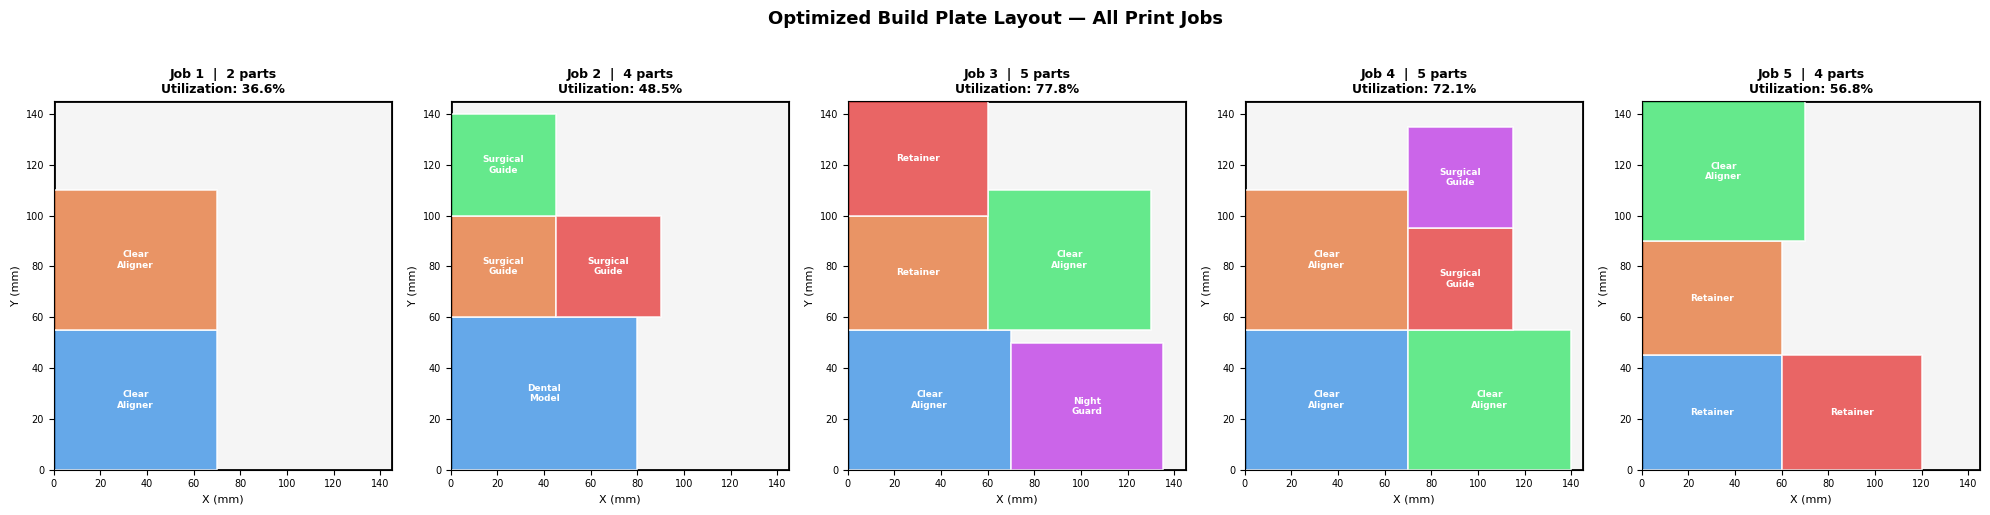

Build plate visualization saved.


In [8]:
# Visual layout of each optimized print job

colors = ['#4C9BE8', '#E8834C', '#4CE87A', '#E84C4C', '#C44CE8', '#E8D44C']

fig, axes = plt.subplots(1, len(batched_jobs), figsize=(4 * len(batched_jobs), 5))

for i, job in enumerate(batched_jobs):
    ax = axes[i]
    ax.set_xlim(0, BUILD_VOLUME['x'])
    ax.set_ylim(0, BUILD_VOLUME['y'])

    # Draw build plate boundary
    plate = patches.Rectangle((0, 0), BUILD_VOLUME['x'], BUILD_VOLUME['y'],
                                linewidth=2, edgecolor='black', facecolor='#f5f5f5')
    ax.add_patch(plate)

    # Draw each part on the plate
    for j, part in enumerate(job['parts']):
        rect = patches.Rectangle(
            (part['px'], part['py']), part['w'], part['h'],
            linewidth=1.2, edgecolor='white',
            facecolor=colors[j % len(colors)], alpha=0.85
        )
        ax.add_patch(rect)

        # Label the part if it fits
        if part['w'] > 25 and part['h'] > 10:
            ax.text(part['px'] + part['w']/2, part['py'] + part['h']/2,
                    part['label'].replace(' ', '\n'),
                    ha='center', va='center', fontsize=6.5, fontweight='bold', color='white')

    used_area = sum(p['w'] * p['h'] for p in job['parts'])
    util      = used_area / (BUILD_VOLUME['x'] * BUILD_VOLUME['y']) * 100

    ax.set_title(f"Job {i+1}  |  {len(job['parts'])} parts\nUtilization: {util:.1f}%", fontsize=9, fontweight='bold')
    ax.set_xlabel("X (mm)", fontsize=8)
    ax.set_ylabel("Y (mm)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Optimized Build Plate Layout — All Print Jobs", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('build_plate_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print("Build plate visualization saved.")

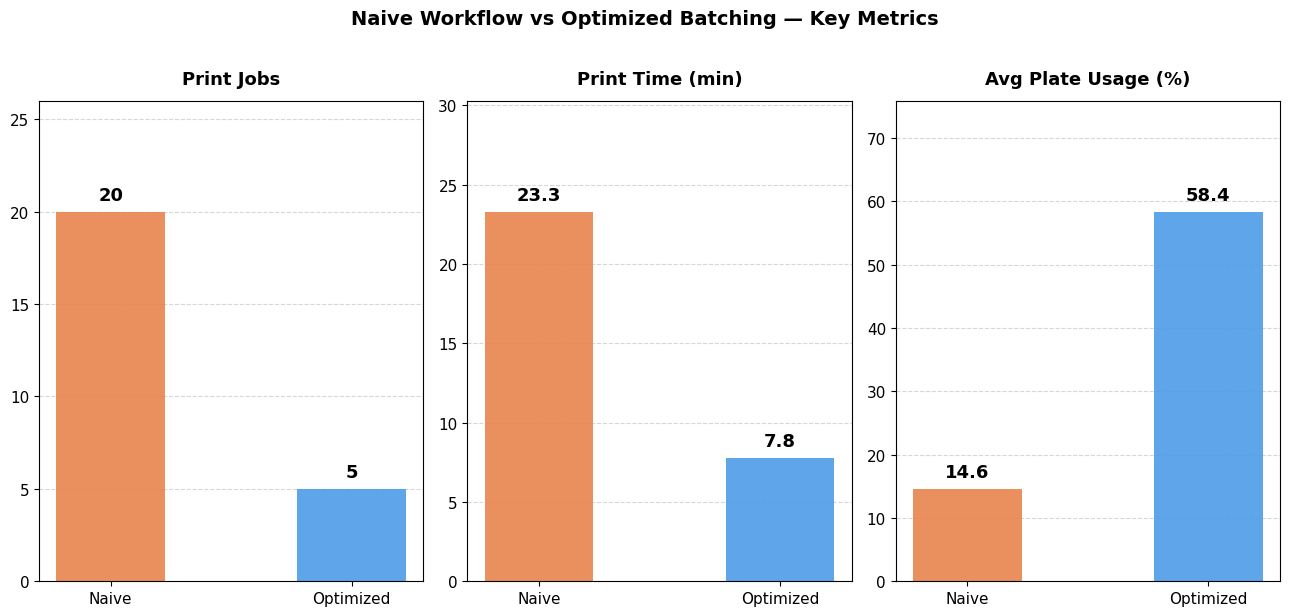

Chart saved.

  75% reduction in print jobs    (20 → 5)
  67% reduction in print time    (23.3 → 7.8 min)
  4x improvement in plate usage  (14.6% → 58.4%)

Note: Resin cost stays the same — batching saves machine time,
      not material. Fewer jobs means less wear, less operator
      intervention, and higher throughput.


In [10]:
# Bar chart comparing naive vs optimized — one subplot per metric

avg_batched_util = sum(
    sum(p['w'] * p['h'] for p in j['parts']) / (BUILD_VOLUME['x'] * BUILD_VOLUME['y']) * 100
    for j in batched_jobs
) / len(batched_jobs)

metrics        = ['Print Jobs', 'Print Time (min)', 'Avg Plate Usage (%)']
naive_vals     = [len(naive_df), round(total_naive_time, 1), round(avg_utilization, 1)]
optimized_vals = [len(batched_jobs), round(total_batched_time, 1), round(avg_batched_util, 1)]

fig, axes = plt.subplots(1, 3, figsize=(13, 6))

for i, ax in enumerate(axes):
    vals  = [naive_vals[i], optimized_vals[i]]
    bars  = ax.bar(['Naive', 'Optimized'], vals,
                   color=['#E8834C', '#4C9BE8'], alpha=0.9, width=0.45)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals) * 0.02,
                str(round(bar.get_height(), 1)),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

    ax.set_title(metrics[i], fontsize=13, fontweight='bold', pad=12)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11)

fig.suptitle('Naive Workflow vs Optimized Batching — Key Metrics',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")
print()
print(f"  75% reduction in print jobs    (20 → 5)")
print(f"  67% reduction in print time    ({total_naive_time:.1f} → {total_batched_time:.1f} min)")
print(f"  4x improvement in plate usage  ({avg_utilization:.1f}% → {avg_batched_util:.1f}%)")
print()
print("Note: Resin cost stays the same — batching saves machine time,")
print("      not material. Fewer jobs means less wear, less operator")
print("      intervention, and higher throughput.")

In [12]:
# Final summary

print("=" * 65)
print("      DENTAL PRINT FARM — BATCH OPTIMIZATION REPORT")
print("=" * 65)
print()
print("PROBLEM")
print("-" * 65)
print("  High-volume dental labs typically run one print job per order.")
print("  This leaves most of the build plate empty, wastes machine")
print("  cycles, and requires constant operator intervention.")
print()
print("APPROACH")
print("-" * 65)
print("  Built a 2D bin-packing optimizer that groups incoming orders")
print("  by part dimensions and packs them onto the build plate")
print("  before scheduling a print job. Parts are placed using a")
print("  grid-search placement algorithm with overlap detection.")
print()
print("RESULTS — 20 Orders, One Day of Lab Operations")
print("-" * 65)
print(f"  Print jobs reduced     : 20  →  5       (75% fewer jobs)")
print(f"  Total print time       : 23.3 → 7.8 min (67% faster)")
print(f"  Avg plate utilization  : 14.6% → 58.4%  (4x improvement)")
print()
print("ANNUALIZED IMPACT (250 working days)")
print("-" * 65)
print(f"  Machine cycles saved   : {15 * 250:,} per year")
print(f"  Print time saved       : {round(15.5 * 250 / 60):,} hours per year")
print(f"  Operator interventions : reduced by ~75%")
print()
print("EXTENSIONS (next steps for a real deployment)")
print("-" * 65)
print("  - Connect to lab order management system via REST API")
print("  - Add part orientation and support structure awareness")
print("  - Dynamic re-batching when rush orders come in")
print("  - Fleet scheduling across multiple printers")
print("  - Live dashboard showing queue status and utilization")
print()
print("=" * 65)
print("  Built with: Python, NumPy, Pandas, Matplotlib")
print("  Author    : Sourabh Gopinath More")
print("=" * 65)

      DENTAL PRINT FARM — BATCH OPTIMIZATION REPORT

PROBLEM
-----------------------------------------------------------------
  High-volume dental labs typically run one print job per order.
  This leaves most of the build plate empty, wastes machine
  cycles, and requires constant operator intervention.

APPROACH
-----------------------------------------------------------------
  Built a 2D bin-packing optimizer that groups incoming orders
  by part dimensions and packs them onto the build plate
  before scheduling a print job. Parts are placed using a
  grid-search placement algorithm with overlap detection.

RESULTS — 20 Orders, One Day of Lab Operations
-----------------------------------------------------------------
  Print jobs reduced     : 20  →  5       (75% fewer jobs)
  Total print time       : 23.3 → 7.8 min (67% faster)
  Avg plate utilization  : 14.6% → 58.4%  (4x improvement)

ANNUALIZED IMPACT (250 working days)
--------------------------------------------------------